In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go
import plotly.express as px
import math

In [2]:
df = pd.read_csv('IoTPond9.csv')
df.head()

,created_at,DATE,entry_id,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Fish_length(cm),Fish_weight(g)
0,2021-06-18 12:11:39 CET,18-06-2021,1,27.7,97,7.329,8.48358,0.05393,0,6.947143,4.371429
1,2021-06-18 12:12:08 CET,18-06-2021,2,27.7,97,7.659,8.40641,0.13203,0,6.947143,4.371429
2,2021-06-18 12:12:28 CET,18-06-2021,3,27.7,96,11.230,8.41095,0.27792,0,6.947143,4.371429
3,2021-06-18 12:12:48 CET,18-06-2021,4,27.0,45,9.828,8.40641,0.04398,813,6.947143,4.371429
4,2021-06-18 12:13:07 CET,18-06-2021,5,27.0,45,9.623,8.40641,0.00052,1255,6.947143,4.371429


In [3]:
df.drop(['DATE','entry_id'],axis=1,inplace=True)

In [ ]:
df.columns

In [4]:
print(df.isnull().sum())

created_at                0
Temperature(C)            0
Turbidity(NTU)            0
Dissolved Oxygen(g/ml)    0
PH                        0
Ammonia(g/ml)             0
Nitrate(g/ml)             0
Fish_length(cm)           0
Fish_weight(g)            0
dtype: int64


In [5]:
df.shape

(151785, 9)

In [6]:
df['created_at'] = pd.to_datetime(df['created_at'], infer_datetime_format=True, utc=True)

In [7]:
df['created_at'] = pd.to_datetime(df.created_at)

#split columns
df["Date"] = df["created_at"].dt.day
df["month"] = df["created_at"].dt.month
df['year']=df['created_at'].dt.year
df['hour']=df['created_at'].dt.hour
df['minutes']=df['created_at'].dt.minute
df['seconds']=df['created_at'].dt.second

In [8]:
df.drop(["created_at"], axis = 1, inplace = True)

In [9]:
 df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Date'] = pd.to_numeric(df['Date'])

In [10]:
 df['month'] = pd.to_datetime(df['month'], errors='coerce')

df['month'] = pd.to_numeric(df['month'])

In [11]:
 df['year'] = pd.to_datetime(df['year'], errors='coerce')

df['year'] = pd.to_numeric(df['year'])

In [12]:
df['hour'] = pd.to_datetime(df['hour'], errors='coerce')

df['hour'] = pd.to_numeric(df['hour'])

In [13]:
df['minutes'] = pd.to_datetime(df['minutes'], errors='coerce')

df['minutes'] = pd.to_numeric(df['minutes'])

In [14]:
df['seconds'] = pd.to_datetime(df['seconds'], errors='coerce')

df['seconds'] = pd.to_numeric(df['seconds'])

In [15]:
df.fillna(df.mean(), inplace=True)
df.replace([np.inf, -np.inf], 1e-9, inplace=True)

In [16]:
df.describe()

,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Fish_length(cm),Fish_weight(g),Date,month,year,hour,minutes,seconds
count,151785.000000,151785.000000,151785.000000,151785.000000,1.517850e+05,151785.000000,151785.000000,151785.000000,151785.000000,151785.000000,151785.0,151785.000000,151785.000000,151785.000000
mean,24.196939,33.068432,14.385698,6.178923,1.618054e+07,568.741358,22.474962,171.760342,16.076384,7.971585,2021.0,11.940989,29.522786,29.531950
std,0.960317,49.967241,13.266113,1.856972,2.134729e+09,509.815251,10.365418,162.824129,9.480749,1.374822,0.0,6.973599,17.369477,17.318985
min,-127.000000,-57.000000,0.007000,2.110170,1.000000e-04,0.000000,6.947143,4.371429,1.000000,6.000000,2021.0,0.000000,0.000000,0.000000
25%,23.625000,-10.000000,4.621000,4.003130,2.068200e-01,113.000000,13.362857,27.771429,8.000000,7.000000,2021.0,6.000000,14.000000,15.000000
50%,24.125000,10.000000,8.634000,7.244310,5.549500e-01,160.000000,17.045714,49.000000,17.000000,7.000000,2021.0,12.000000,30.000000,30.000000
75%,24.687500,91.000000,20.547000,7.462200,1.143020e+00,1074.000000,33.862857,354.285714,25.000000,9.000000,2021.0,18.000000,45.000000,45.000000
max,27.700000,100.000000,44.980000,15.451660,4.270000e+11,2269.000000,36.154286,431.200000,31.000000,10.000000,2021.0,23.000000,59.000000,59.000000


In [17]:
for i in range(len(df)):
    if df.loc[i, "Temperature(C)"] < 20 or df.loc[i, "Temperature(C)"] > 30:
        df.loc[i, "Temperature(C)"] = df.loc[i-1, "Temperature(C)"]

In [18]:
for i in range(1,len(df)):
    if df.loc[i, "PH"] < 6 or df.loc[i, "PH"] > 8.5:
        df.loc[i, "PH"] = df.loc[i-1,'PH']

In [19]:
for i in range(1,len(df)):
    if df.loc[i, "Dissolved Oxygen(g/ml)"] < 5 or df.loc[i, "Dissolved Oxygen(g/ml)"] > 20:
        df.loc[i, "Dissolved Oxygen(g/ml)"] = df.loc[i-1, "Dissolved Oxygen(g/ml)"]

In [20]:
df["Ammonia(g/ml)"] = np.log(df["Ammonia(g/ml)"]) / 10.0
df["Ammonia(g/ml)"] = df["Ammonia(g/ml)"].abs()


In [21]:
df["Nitrate(g/ml)"] = df["Nitrate(g/ml)"].apply(np.sqrt)

In [22]:
for i in range(1,len(df)):
    if df.loc[i, "Turbidity(NTU)"] < 0:
        df.loc[i, "Turbidity(NTU)"] = df.loc[i-1, "Turbidity(NTU)"]

In [23]:
df.describe()

,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Fish_length(cm),Fish_weight(g),Date,month,year,hour,minutes,seconds
count,151785.000000,151785.000000,151785.000000,151785.000000,151785.000000,151785.000000,151785.000000,151785.000000,151785.000000,151785.000000,151785.0,151785.000000,151785.000000,151785.000000
mean,24.197941,50.880482,10.033194,6.847922,0.291116,20.990961,22.474962,171.760342,16.076384,7.971585,2021.0,11.940989,29.522786,29.531950
std,0.878408,32.994520,4.315133,0.736626,0.323947,11.319088,10.365418,162.824129,9.480749,1.374822,0.0,6.973599,17.369477,17.318985
min,20.375000,0.000000,5.003000,6.005030,0.000036,0.000000,6.947143,4.371429,1.000000,6.000000,2021.0,0.000000,0.000000,0.000000
25%,23.625000,26.000000,6.479000,6.059510,0.046898,10.630146,13.362857,27.771429,8.000000,7.000000,2021.0,6.000000,14.000000,15.000000
50%,24.125000,28.000000,8.891000,7.244310,0.117215,12.649111,17.045714,49.000000,17.000000,7.000000,2021.0,12.000000,30.000000,30.000000
75%,24.687500,91.000000,12.095000,7.453120,0.590345,32.771939,33.862857,354.285714,25.000000,9.000000,2021.0,18.000000,45.000000,45.000000
max,27.700000,100.000000,19.998000,8.497200,2.678005,47.634021,36.154286,431.200000,31.000000,10.000000,2021.0,23.000000,59.000000,59.000000


In [24]:
columns=df.columns.tolist()
columns=columns[-6:]+columns[0:-6]
df=df[columns]

In [25]:
df.head()

,Date,month,year,hour,minutes,seconds,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Fish_length(cm),Fish_weight(g)
0,18,6,2021,12,11,39,27.7,97,7.329,8.48358,0.292007,0.000000,6.947143,4.371429
1,18,6,2021,12,12,8,27.7,97,7.659,8.40641,0.202473,0.000000,6.947143,4.371429
2,18,6,2021,12,12,28,27.7,96,11.230,8.41095,0.128042,0.000000,6.947143,4.371429
3,18,6,2021,12,12,48,27.0,45,9.828,8.40641,0.312402,28.513155,6.947143,4.371429
4,18,6,2021,12,13,7,27.0,45,9.623,8.40641,0.756168,35.425979,6.947143,4.371429


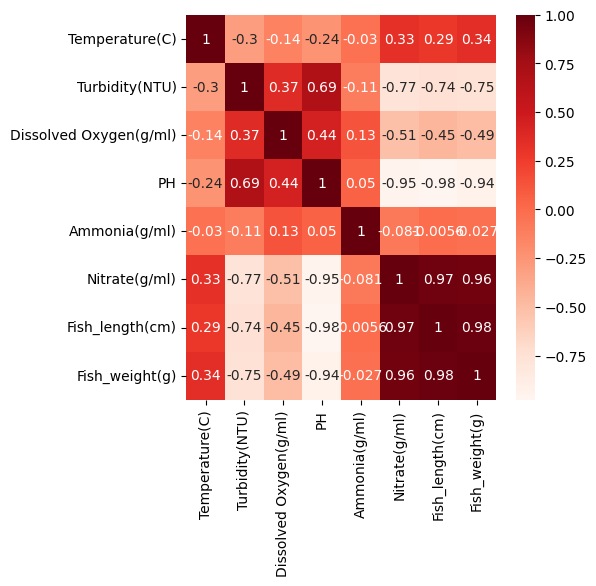

In [26]:
#creating a heatmap to show the correlation between the features
plt.figure(figsize=(5, 5))
x=df.iloc[:,6:]
cor = x.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

In [28]:
df.to_csv('pp9.csv', index=False)